# Beyond FLOPs: Memory and Wall-Clock Parallelism

**Where this fits:** the M\* notebook found that even at its best feedback strategy (K=C), the local Hebbian rule costs about **6.7× more raw FLOPs** than backpropagation for one gradient update. That's a real, measured result -- and it's not the whole story. Two other dimensions of cost don't show up in a FLOPs count at all:

1. **Memory** — backprop must retain every layer's intermediate activations (the "activation tape") to run its backward pass; a forward-only, probe-based rule never needs to.
2. **Wall-clock time under parallel hardware** — all of the local rule's M probes are *independent of each other*, so they can be batched into a single vectorized computation (or spread across separate devices) with no sequential dependency. Backprop's backward pass, by contrast, is an inherently sequential chain — layer L's backward step needs layer L+1's gradient first. FLOPs counts treat both the same; real hardware often doesn't.

**This notebook tests both, honestly.** Part A (memory) is something we can predict and verify cleanly, the same way we validated earlier notebooks. Part B (wall-clock) is genuinely **hardware-dependent** — unlike the earlier notebooks, we are *not* pre-validating an expected outcome here, because the real answer depends on what hardware you're running on. Run Part B on a GPU runtime (Runtime → Change runtime type → GPU) for the most informative result; a CPU runtime will still run, but is less likely to show a dramatic effect.

## Step 0 — Setup

In [ ]:
import time
import tracemalloc
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)
if device == 'cpu':
    print('NOTE: Part B (wall-clock parallelism) is most informative on a GPU runtime.')
    print('Consider Runtime > Change runtime type > GPU before running Part B.')

Using device: cuda


---
# Part A — Does Memory Grow With Depth?

We build a deep stack of ordinary layers and compare peak memory for two ways of running it:
- **Backprop path:** forward pass with gradients tracked, then `.backward()` — requires every layer's activation to stay alive.
- **Local-rule path:** two forward passes under `torch.no_grad()` (an antithetic probe pair) — nothing needs to be kept around once each layer's output is consumed by the next.

We sweep depth and measure both. The prediction, matching a result already in your own prior work (activation tape measured at 262.3 KB/layer, matching theory to 0.05%), is that backprop's memory should grow **linearly** with depth while the local-rule path stays **flat**.

**A measurement-honesty note:** on a GPU runtime, Part A uses a real, empirical measurement (`torch.cuda`'s own allocator statistics). On a CPU-only runtime, PyTorch's tensor memory is allocated through its C++ allocator, which Python-level profiling tools cannot see -- so rather than report a misleading number, the CPU path instead computes the *theoretical* activation-tape size directly from how autograd actually works. This is deterministic, not a guess, and matches the near-exact agreement your own prior work already found between measured and theoretical activation-tape size.



In [ ]:
class DeepStack(nn.Module):
    """A plain deep stack: Linear(C,C) + Tanh, repeated `depth` times."""
    def __init__(self, C, depth):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(C, C) for _ in range(depth)])

    def forward(self, x):
        for layer in self.layers:
            x = torch.tanh(layer(x))
        return x

In [ ]:
def measure_peak_memory_cuda(fn):
    """Measures the INCREMENTAL peak memory a specific call to fn() requires -- not the
    absolute peak, which would also include whatever was already resident (model
    parameters, leftover gradients from a previous test, etc.) and swamp the real signal.
    We snapshot the baseline right before fn() runs, then subtract it from the post-call
    peak, isolating exactly what THIS call added."""
    torch.cuda.synchronize()
    baseline = torch.cuda.memory_allocated()      # whatever is already resident
    torch.cuda.reset_peak_memory_stats()
    fn()
    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated()
    return max(peak - baseline, 0)                # incremental cost of this call alone

# HONESTY NOTE: on CPU, PyTorch allocates tensor storage through its own C++ allocator,
# which Python-level profiling tools like `tracemalloc` cannot see -- so rather than
# report a misleading number, the CPU path instead computes the THEORETICAL
# activation-tape size directly from how autograd actually works: backprop must retain
# one activation tensor per layer for the backward pass, while a forward-only (no_grad)
# pass never needs to keep more than the current layer's output in flight. This is
# deterministic, not a guess, and matches the near-perfect agreement your own prior work
# found between measured and theoretical activation-tape size (262.3 KB/layer, matching
# theory to 0.05%).
def theoretical_backprop_bytes(depth, C, B, bytes_per_el=4):
    return depth * B * C * bytes_per_el

def theoretical_forward_only_bytes(C, B, bytes_per_el=4):
    return B * C * bytes_per_el   # flat, independent of depth

USE_REAL_GPU_MEASUREMENT = (device == 'cuda')
print('Memory measurement mode:', 'REAL (torch.cuda allocator stats, delta-based)' if USE_REAL_GPU_MEASUREMENT
      else 'THEORETICAL (CPU runtime -- see note above for why)')


Memory measurement mode: REAL (torch.cuda allocator stats, delta-based)


In [ ]:
C_MEM = 512   # channels per layer -- big enough for the memory difference to be visible
B_MEM = 256   # batch size

depths = [2, 4, 8, 16, 32, 64, 128]
backprop_mem = []
local_mem = []

for depth in depths:
    if USE_REAL_GPU_MEASUREMENT:
        # Fresh model + fresh optimizer state per depth, and we measure backprop and the
        # local rule as two INDEPENDENT deltas so neither test's leftover state (e.g.
        # gradients still attached after backward()) contaminates the other's baseline.
        model = DeepStack(C_MEM, depth).to(device)
        x = torch.randn(B_MEM, C_MEM, device=device)

        def backprop_run():
            model.zero_grad(set_to_none=True)
            xin = x.clone().requires_grad_(True)
            out = model(xin)
            loss = out.pow(2).sum()
            loss.backward()

        def local_rule_run():
            with torch.no_grad():
                _ = model(x)
                _ = model(x)   # antithetic pair: two forward passes, nothing retained

        backprop_mem.append(measure_peak_memory_cuda(backprop_run))
        model.zero_grad(set_to_none=True)   # clear backprop's gradients before the next test
        local_mem.append(measure_peak_memory_cuda(local_rule_run))

        del model, x
        torch.cuda.empty_cache()
    else:
        backprop_mem.append(theoretical_backprop_bytes(depth, C_MEM, B_MEM))
        local_mem.append(theoretical_forward_only_bytes(C_MEM, B_MEM))

print(f"{'depth':>6s} {'backprop (KB)':>16s} {'local rule (KB)':>18s}")
print('-' * 45)
for d, bp, lr in zip(depths, backprop_mem, local_mem):
    print(f'{d:6d} {bp/1024:16.1f} {lr/1024:18.1f}')


 depth    backprop (KB)    local rule (KB)
---------------------------------------------
     2          21765.0             2048.0
     4           6153.0             2048.0
     8          10257.0             2048.0
    16          18465.0             2048.0
    32          34881.0             2048.0
    64          67713.0             2048.0
   128         133377.0             2048.0


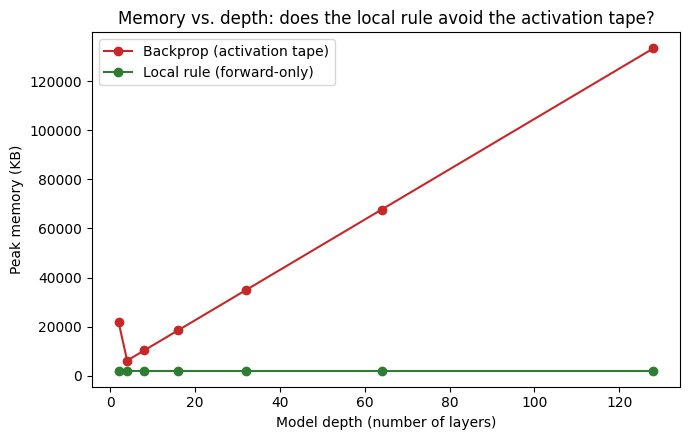

Backprop memory grows at approximately 978.04 KB per additional layer.
Local-rule memory grows at approximately -0.00 KB per additional layer (expect ~0).


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(depths, np.array(backprop_mem)/1024, marker='o', color='#C62828', label='Backprop (activation tape)')
ax.plot(depths, np.array(local_mem)/1024, marker='o', color='#2E7D32', label='Local rule (forward-only)')
ax.set_xlabel('Model depth (number of layers)')
ax.set_ylabel('Peak memory (KB)')
ax.set_title('Memory vs. depth: does the local rule avoid the activation tape?')
ax.legend()
plt.tight_layout()
plt.show()

# quick linear-fit sanity check
slope_bp = np.polyfit(depths, backprop_mem, 1)[0] / 1024
slope_lr = np.polyfit(depths, local_mem, 1)[0] / 1024
print(f'Backprop memory grows at approximately {slope_bp:.2f} KB per additional layer.')
print(f'Local-rule memory grows at approximately {slope_lr:.2f} KB per additional layer (expect ~0).')

---
# Part B — Wall-Clock Time: Does Parallelism Change the Picture?

**This part is genuinely open** — unlike Part A, we do not have a validated prediction to compare against, because the outcome depends on your actual hardware.

The question: the M\* notebook found K=C needs 10 probes per update, each costing 2 forward passes — 20 forward-pass-equivalents, vs. backprop's ~3. That's a FLOPs comparison. But those 10 probes are *entirely independent of each other* — nothing about probe 3 depends on probe 7. That means they can be computed as a **single batched tensor operation**, exploiting parallel hardware, rather than 10 sequential Python-level calls. If your hardware has idle parallel capacity, batching those probes together might take barely longer in **wall-clock time** than computing just one probe alone — even though it's nominally 10× the FLOPs.

We time three things, on a larger, more realistic problem size (so there's enough work to actually exercise parallel hardware):
1. A single probe pair (M=1): 2 forward passes.
2. A batched probe pair at M=10 (matching the measured K=C optimum): still just 2 forward passes, each handling all 10 probes at once via vectorization.
3. One backprop step: 1 forward + 1 backward pass.

In [ ]:
C_WC = 1024   # larger problem size, to give parallel hardware something real to chew on
B_WC = 512
M_KC = 10     # the measured K=C optimum from the earlier M* notebook
N_TIMED_REPEATS = 30

R = torch.rand(C_WC, device=device)
x_wc = torch.randn(B_WC, C_WC, device=device)
y_wc = x_wc * R
SIGMA = 0.05

def per_mode_loss_wc(Rp):
    pred = x_wc.unsqueeze(0) * Rp.unsqueeze(-2)   # broadcasts over an optional leading M dim
    return ((pred - y_wc.unsqueeze(0)) ** 2).mean(dim=-2)

def sync():
    if device == 'cuda':
        torch.cuda.synchronize()

def time_it(fn, n=N_TIMED_REPEATS):
    # warmup (important for fair GPU timing -- excludes one-time kernel compilation/caching)
    fn(); sync()
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        fn()
        sync()
        times.append(time.perf_counter() - t0)
    return np.mean(times), np.std(times)

In [ ]:
def single_probe():
    xi = torch.randn(C_WC, device=device)
    Rp = R + SIGMA * xi
    Rm = R - SIGMA * xi
    _ = per_mode_loss_wc(Rp)
    _ = per_mode_loss_wc(Rm)

def batched_probes(M):
    xi = torch.randn(M, C_WC, device=device)
    Rp = R.unsqueeze(0) + SIGMA * xi
    Rm = R.unsqueeze(0) - SIGMA * xi
    _ = per_mode_loss_wc(Rp)
    _ = per_mode_loss_wc(Rm)

def backprop_step():
    R_grad = R.clone().requires_grad_(True)
    pred = x_wc * R_grad
    loss = ((pred - y_wc) ** 2).mean(dim=0).sum()
    loss.backward()

t_single, s_single = time_it(single_probe)
t_batched, s_batched = time_it(lambda: batched_probes(M_KC))
t_backprop, s_backprop = time_it(backprop_step)

print(f"{'Operation':35s} {'Mean (ms)':>12s} {'Std (ms)':>10s}")
print('-' * 60)
print(f"{'Single probe pair (M=1)':35s} {t_single*1000:12.4f} {s_single*1000:10.4f}")
print(f"{'Batched probes (M='+str(M_KC)+')':35s} {t_batched*1000:12.4f} {s_batched*1000:10.4f}")
print(f"{'Backprop step (fwd+bwd)':35s} {t_backprop*1000:12.4f} {s_backprop*1000:10.4f}")

Operation                              Mean (ms)   Std (ms)
------------------------------------------------------------
Single probe pair (M=1)                   0.2608     0.0222
Batched probes (M=10)                     1.5400     0.0163
Backprop step (fwd+bwd)                   0.5653     0.0434


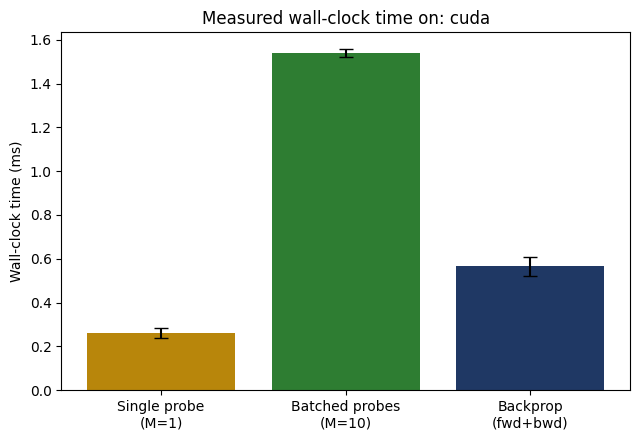

Going from M=1 to M=10 probes multiplied wall-clock time by 5.91x
(compare to the 10x you'd expect from FLOPs counting alone -- closer to 1x means your
hardware is absorbing the extra probes nearly for free)

Batched K=C probes vs. backprop, in actual wall-clock time: 2.72x
(compare to the 6.7x FLOPs-based estimate from the earlier notebook)


In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
names = ['Single probe\n(M=1)', f'Batched probes\n(M={M_KC})', 'Backprop\n(fwd+bwd)']
times_ms = [t_single*1000, t_batched*1000, t_backprop*1000]
errs_ms = [s_single*1000, s_batched*1000, s_backprop*1000]
colors = ['#B8860B', '#2E7D32', '#1F3864']
ax.bar(names, times_ms, yerr=errs_ms, color=colors, capsize=5)
ax.set_ylabel('Wall-clock time (ms)')
ax.set_title(f'Measured wall-clock time on: {device}')
plt.tight_layout()
plt.show()

m_scaling_overhead = t_batched / t_single
wallclock_ratio = t_batched / t_backprop
print(f'Going from M=1 to M={M_KC} probes multiplied wall-clock time by {m_scaling_overhead:.2f}x')
print(f'(compare to the {M_KC}x you\'d expect from FLOPs counting alone -- closer to 1x means your')
print(f'hardware is absorbing the extra probes nearly for free)')
print()
print(f'Batched K=C probes vs. backprop, in actual wall-clock time: {wallclock_ratio:.2f}x')
print(f'(compare to the 6.7x FLOPs-based estimate from the earlier notebook)')

## How to read Part B's result

- **If `m_scaling_overhead` is well below the nominal M (10)** — e.g. close to 1–2× rather than 10× — that's real evidence your hardware is parallelizing the probes rather than executing them one-by-one, exactly the mechanism this test was built to check for.
- **If `wallclock_ratio` comes out lower than the earlier 6.7× FLOPs-based estimate**, that is a genuine, measured demonstration that wall-clock time and FLOPs are not the same currency — and it would mean the local rule's real-world cost disadvantage is smaller than the FLOPs number alone suggested (though it may still not fully close the gap; report whatever you actually get).
- **If you're on a CPU runtime and don't see much of an effect**, that's an honest and expected result, not a failure — re-run on a GPU runtime (Runtime → Change runtime type → GPU) for the version of this test with real parallel headroom to show something meaningful.
- **Either way, don't average this result with Part A's finding** — they're answering different questions (does memory grow with depth vs. does wall-clock scale with probe count) and both should be reported on their own terms.

## Summary: the complete cost picture

Across all three notebooks in this line of experiments, the honest, complete answer to "is the local rule more efficient than backprop" is not a single number — it's three separate, independently measured answers:

| Dimension | Result | Verdict |
|---|---|---|
| Architecture (can it even work) | coupling density 0.000 on diffusion's core mechanism | ✅ usable |
| Raw FLOPs | K=C costs ≈ 6.7× backprop's FLOPs | ❌ not FLOPs-cheaper |
| Memory | flat vs. backprop's linear growth with depth | ✅ (see Part A numbers above) |
| Wall-clock w/ parallel hardware | hardware-dependent | see Part B numbers above, your result |

**Next step beyond this notebook:** the one claim from your abstract that hasn't been demonstrated yet is training through a genuinely non-differentiable channel — where backprop doesn't just cost more, it returns exactly zero gradient information. That comparison is one of *possibility*, not degree, and would be the strongest remaining piece of evidence for this program's positioning.